<a href="https://colab.research.google.com/github/divyamjariwal/Deep-Learning-Lab/blob/main/DL_lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB EXPERIMENT 4

Installing Libraries

In [1]:
!pip install torch torchvision tqdm seaborn scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Loading CIFAR-10 Dataset

In [4]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

classes = train_data.classes


100%|██████████| 170M/170M [00:10<00:00, 16.0MB/s]


Dataset Examples

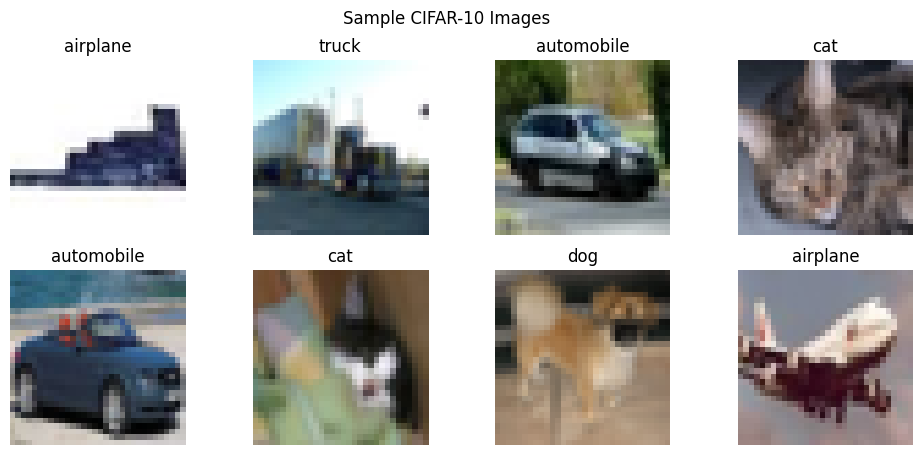

In [5]:
def show_images():
    images, labels = next(iter(train_loader))
    images, labels = images[:8], labels[:8]

    plt.figure(figsize=(12,5))
    for i in range(8):
        plt.subplot(2,4,i+1)
        img = images[i] * 0.5 + 0.5
        plt.imshow(np.transpose(img.numpy(), (1,2,0)))
        plt.title(classes[labels[i]])
        plt.axis("off")

    plt.suptitle("Sample CIFAR-10 Images")
    plt.show()

show_images()


CNN Model Definition

In [6]:
class CNN(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, 10)

        if activation == "relu":
            self.act = nn.ReLU()
        elif activation == "tanh":
            self.act = nn.Tanh()
        elif activation == "leakyrelu":
            self.act = nn.LeakyReLU(0.01)

    def forward(self, x):
        x = self.pool(self.act(self.conv1(x)))
        x = self.pool(self.act(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.act(self.fc1(x)))
        return self.fc2(x)


Weight Initialization Methods

In [7]:
def init_weights(model, method):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if method == "random":
                nn.init.uniform_(m.weight)
            elif method == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif method == "kaiming":
                nn.init.kaiming_uniform_(m.weight)

Training Function(with loss tracking)

In [8]:
def train_model(model, optimizer, criterion, epochs=5):
    model.train()
    losses = []

    for epoch in range(epochs):
        total_loss = 0
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    return losses


Evaluation Function

In [9]:
def evaluate_model(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    return acc


ALL COMBINATIONS


Activation=relu, Init=random, Optimizer=sgd


100%|██████████| 782/782 [01:27<00:00,  8.99it/s]


Epoch 1, Loss: 4221.9987


100%|██████████| 782/782 [01:23<00:00,  9.37it/s]


Epoch 2, Loss: 2.3027


100%|██████████| 782/782 [01:24<00:00,  9.27it/s]


Epoch 3, Loss: 2.3027


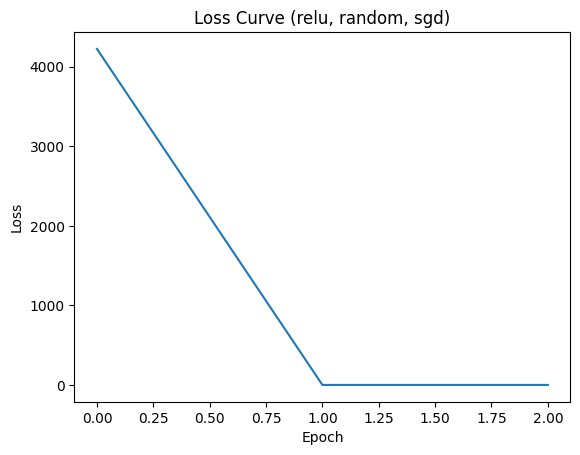


Activation=relu, Init=random, Optimizer=adam


100%|██████████| 782/782 [01:30<00:00,  8.66it/s]


Epoch 1, Loss: 693696.2400


100%|██████████| 782/782 [01:31<00:00,  8.53it/s]


Epoch 2, Loss: 6651.1445


100%|██████████| 782/782 [01:29<00:00,  8.76it/s]


Epoch 3, Loss: 177.5806


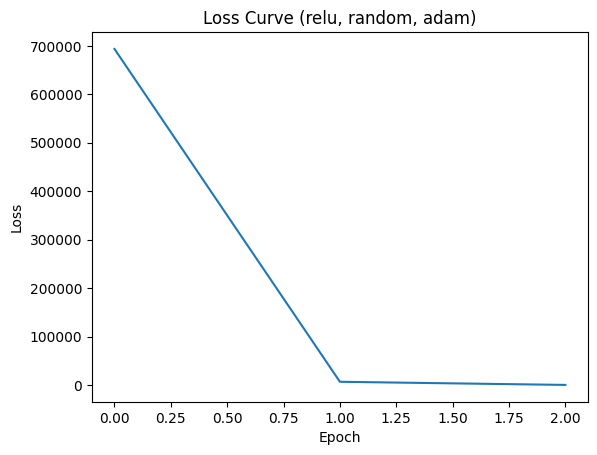


Activation=relu, Init=random, Optimizer=rmsprop


100%|██████████| 782/782 [01:29<00:00,  8.73it/s]


Epoch 1, Loss: 320885.1920


100%|██████████| 782/782 [01:26<00:00,  9.01it/s]


Epoch 2, Loss: 37.5962


100%|██████████| 782/782 [01:27<00:00,  8.94it/s]


Epoch 3, Loss: 2.5749


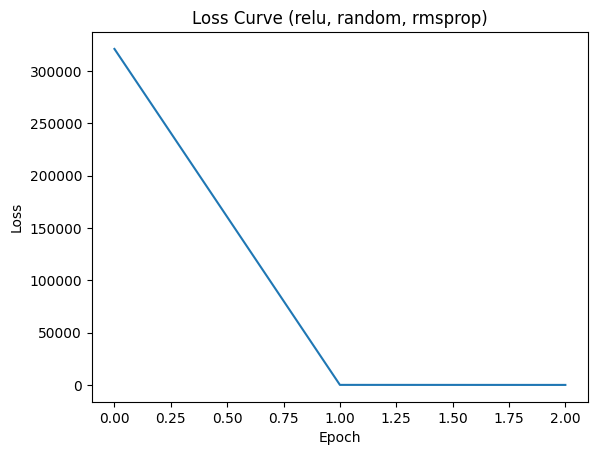


Activation=relu, Init=xavier, Optimizer=sgd


100%|██████████| 782/782 [01:30<00:00,  8.61it/s]


Epoch 1, Loss: 1.9094


100%|██████████| 782/782 [01:31<00:00,  8.57it/s]


Epoch 2, Loss: 1.5854


100%|██████████| 782/782 [01:31<00:00,  8.51it/s]


Epoch 3, Loss: 1.4394


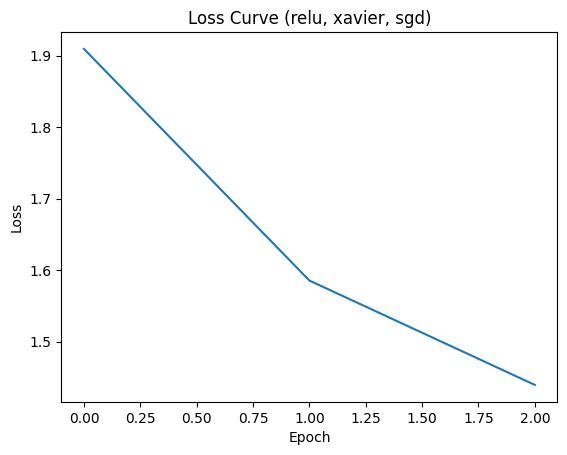


Activation=relu, Init=xavier, Optimizer=adam


100%|██████████| 782/782 [01:36<00:00,  8.14it/s]


Epoch 1, Loss: 1.4359


100%|██████████| 782/782 [01:37<00:00,  8.01it/s]


Epoch 2, Loss: 1.0892


100%|██████████| 782/782 [01:38<00:00,  7.98it/s]


Epoch 3, Loss: 0.9553


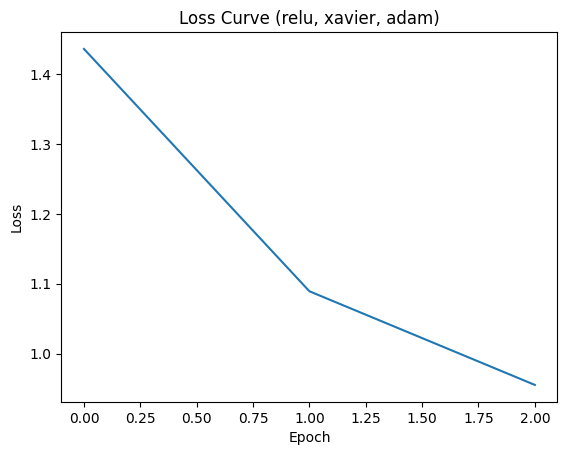


Activation=relu, Init=xavier, Optimizer=rmsprop


100%|██████████| 782/782 [01:32<00:00,  8.48it/s]


Epoch 1, Loss: 1.4045


100%|██████████| 782/782 [01:31<00:00,  8.52it/s]


Epoch 2, Loss: 1.0398


100%|██████████| 782/782 [01:32<00:00,  8.50it/s]


Epoch 3, Loss: 0.9043


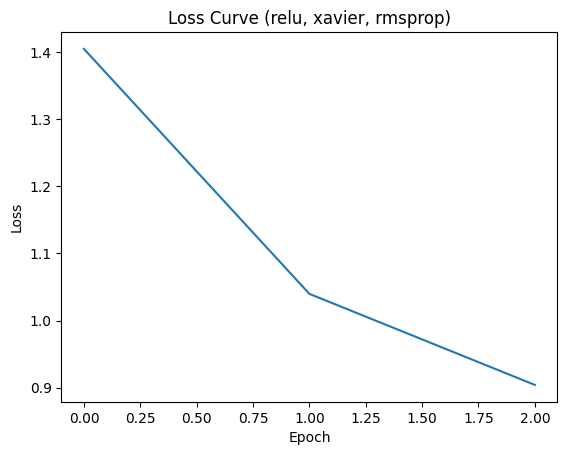


Activation=relu, Init=kaiming, Optimizer=sgd


100%|██████████| 782/782 [01:33<00:00,  8.40it/s]


Epoch 1, Loss: 1.7380


100%|██████████| 782/782 [01:33<00:00,  8.40it/s]


Epoch 2, Loss: 1.4339


100%|██████████| 782/782 [01:33<00:00,  8.41it/s]


Epoch 3, Loss: 1.3089


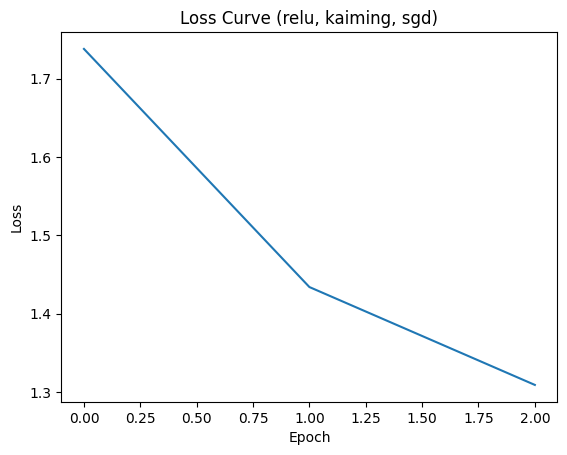


Activation=relu, Init=kaiming, Optimizer=adam


100%|██████████| 782/782 [01:35<00:00,  8.15it/s]


Epoch 1, Loss: 1.4609


100%|██████████| 782/782 [01:39<00:00,  7.86it/s]


Epoch 2, Loss: 1.1058


100%|██████████| 782/782 [01:39<00:00,  7.89it/s]


Epoch 3, Loss: 0.9792


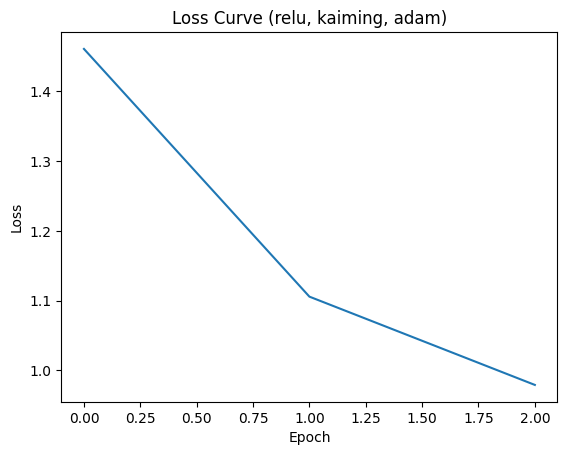


Activation=relu, Init=kaiming, Optimizer=rmsprop


100%|██████████| 782/782 [01:33<00:00,  8.35it/s]


Epoch 1, Loss: 1.5404


100%|██████████| 782/782 [01:32<00:00,  8.42it/s]


Epoch 2, Loss: 1.0861


100%|██████████| 782/782 [01:32<00:00,  8.42it/s]


Epoch 3, Loss: 0.9447


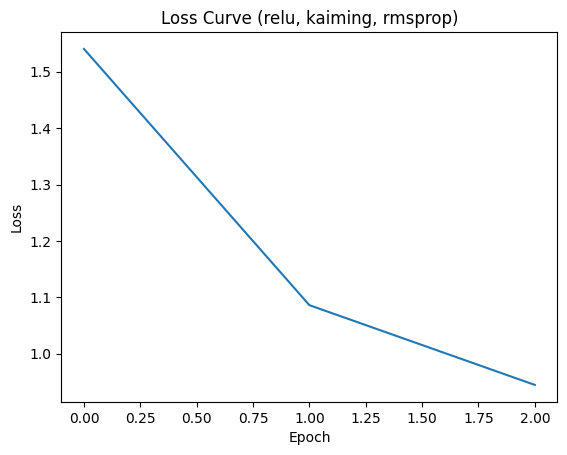


Activation=tanh, Init=random, Optimizer=sgd


100%|██████████| 782/782 [01:34<00:00,  8.27it/s]


Epoch 1, Loss: 3.4845


100%|██████████| 782/782 [01:35<00:00,  8.17it/s]


Epoch 2, Loss: 3.0920


100%|██████████| 782/782 [01:34<00:00,  8.28it/s]


Epoch 3, Loss: 2.8282


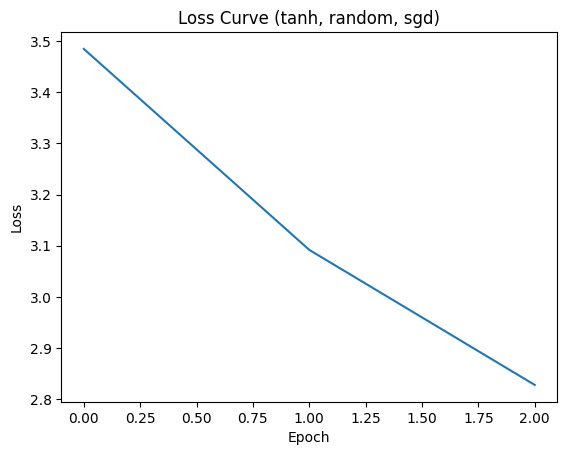


Activation=tanh, Init=random, Optimizer=adam


100%|██████████| 782/782 [01:37<00:00,  8.03it/s]


Epoch 1, Loss: 3.3587


100%|██████████| 782/782 [01:37<00:00,  8.00it/s]


Epoch 2, Loss: 2.7938


100%|██████████| 782/782 [01:37<00:00,  8.01it/s]


Epoch 3, Loss: 2.4790


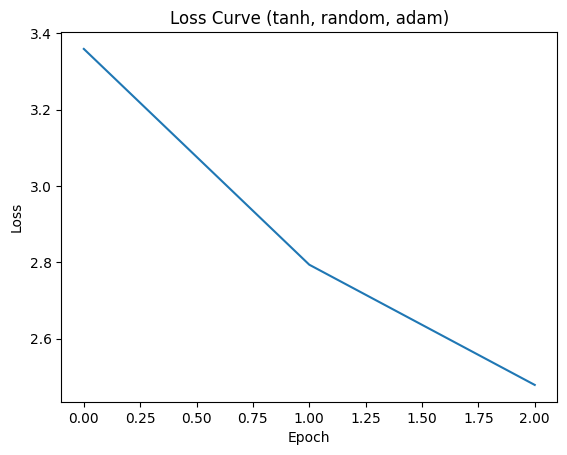


Activation=tanh, Init=random, Optimizer=rmsprop


100%|██████████| 782/782 [01:36<00:00,  8.08it/s]


Epoch 1, Loss: 3.2069


100%|██████████| 782/782 [01:37<00:00,  8.04it/s]


Epoch 2, Loss: 2.6704


100%|██████████| 782/782 [01:36<00:00,  8.07it/s]


Epoch 3, Loss: 2.4159


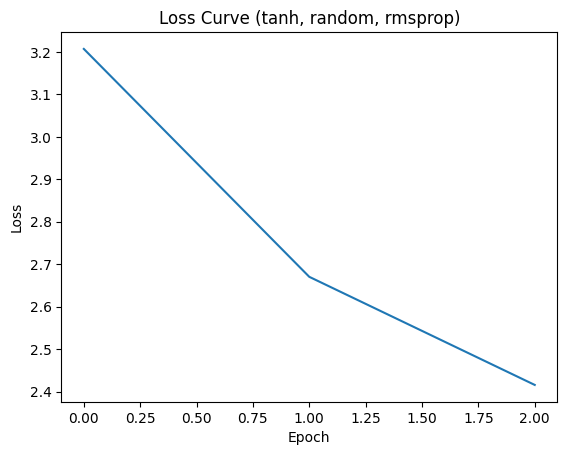


Activation=tanh, Init=xavier, Optimizer=sgd


100%|██████████| 782/782 [01:42<00:00,  7.62it/s]


Epoch 1, Loss: 1.7623


100%|██████████| 782/782 [01:42<00:00,  7.61it/s]


Epoch 2, Loss: 1.5022


100%|██████████| 782/782 [01:42<00:00,  7.63it/s]


Epoch 3, Loss: 1.3689


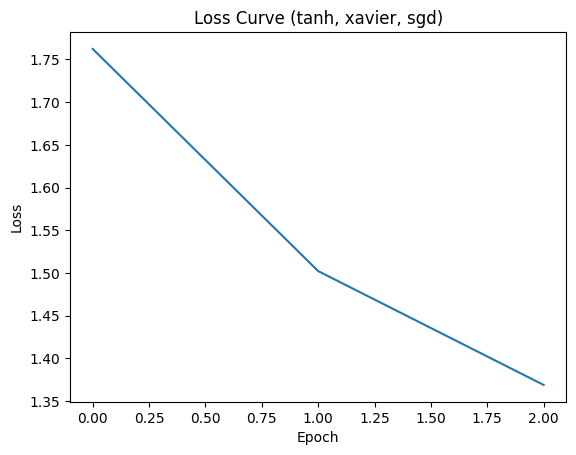


Activation=tanh, Init=xavier, Optimizer=adam


100%|██████████| 782/782 [01:44<00:00,  7.49it/s]


Epoch 1, Loss: 1.3434


100%|██████████| 782/782 [01:44<00:00,  7.45it/s]


Epoch 2, Loss: 1.0522


100%|██████████| 782/782 [01:43<00:00,  7.53it/s]


Epoch 3, Loss: 0.9596


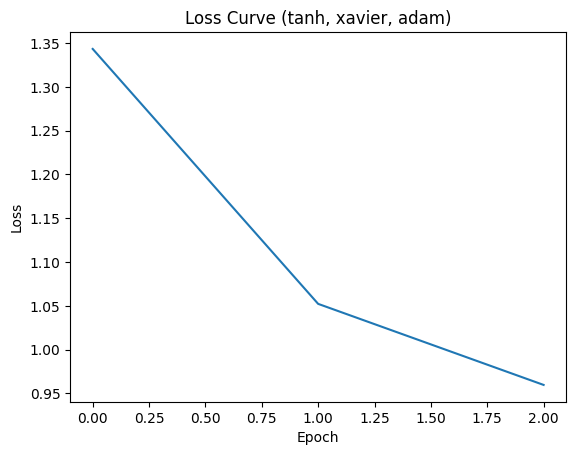


Activation=tanh, Init=xavier, Optimizer=rmsprop


100%|██████████| 782/782 [01:42<00:00,  7.60it/s]


Epoch 1, Loss: 1.4805


100%|██████████| 782/782 [01:43<00:00,  7.56it/s]


Epoch 2, Loss: 1.0769


100%|██████████| 782/782 [01:44<00:00,  7.52it/s]


Epoch 3, Loss: 0.9677


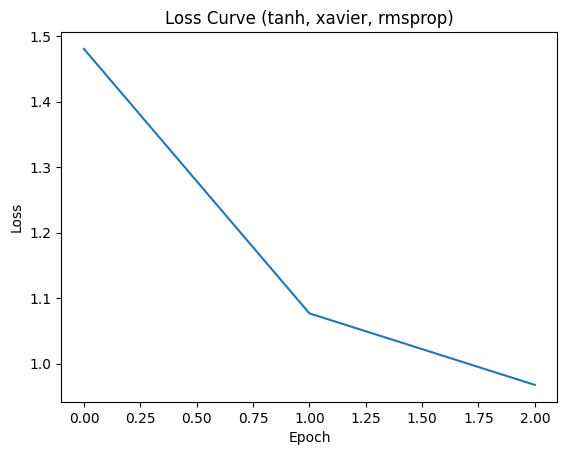


Activation=tanh, Init=kaiming, Optimizer=sgd


100%|██████████| 782/782 [01:42<00:00,  7.63it/s]


Epoch 1, Loss: 1.6432


100%|██████████| 782/782 [01:43<00:00,  7.58it/s]


Epoch 2, Loss: 1.3460


100%|██████████| 782/782 [01:43<00:00,  7.55it/s]


Epoch 3, Loss: 1.2117


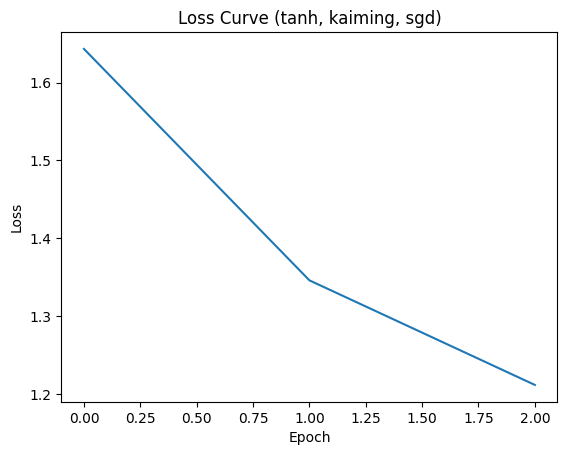


Activation=tanh, Init=kaiming, Optimizer=adam


100%|██████████| 782/782 [01:45<00:00,  7.38it/s]


Epoch 1, Loss: 1.3582


100%|██████████| 782/782 [01:47<00:00,  7.29it/s]


Epoch 2, Loss: 1.0295


100%|██████████| 782/782 [01:46<00:00,  7.35it/s]


Epoch 3, Loss: 0.9333


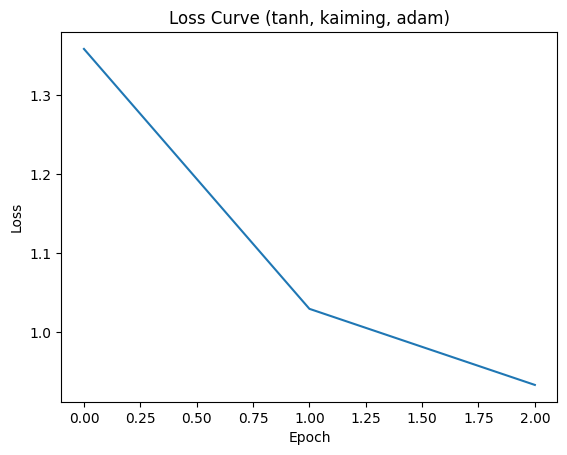


Activation=tanh, Init=kaiming, Optimizer=rmsprop


100%|██████████| 782/782 [01:44<00:00,  7.47it/s]


Epoch 1, Loss: 1.5380


100%|██████████| 782/782 [01:44<00:00,  7.50it/s]


Epoch 2, Loss: 1.0993


100%|██████████| 782/782 [01:44<00:00,  7.51it/s]


Epoch 3, Loss: 0.9826


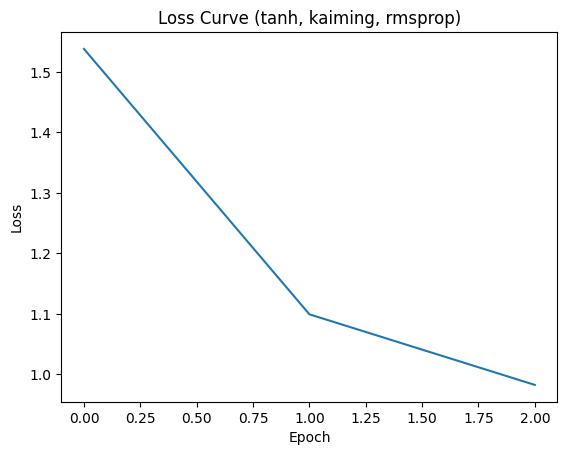


Activation=leakyrelu, Init=random, Optimizer=sgd


100%|██████████| 782/782 [01:27<00:00,  8.91it/s]


Epoch 1, Loss: nan


100%|██████████| 782/782 [01:27<00:00,  8.93it/s]


Epoch 2, Loss: nan


100%|██████████| 782/782 [01:27<00:00,  8.92it/s]


Epoch 3, Loss: nan


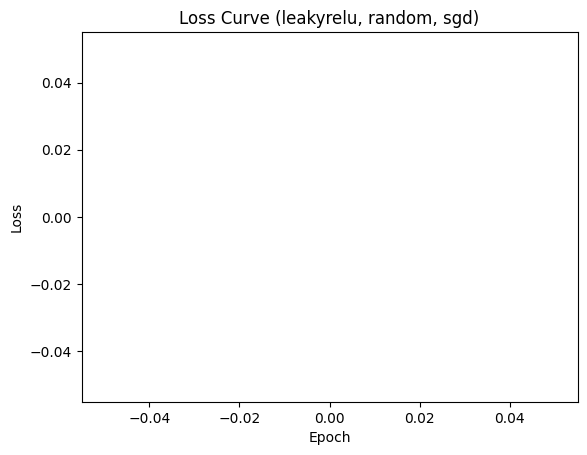


Activation=leakyrelu, Init=random, Optimizer=adam


100%|██████████| 782/782 [01:35<00:00,  8.20it/s]


Epoch 1, Loss: 679454.2920


100%|██████████| 782/782 [01:47<00:00,  7.30it/s]


Epoch 2, Loss: 3249.3012


100%|██████████| 782/782 [01:40<00:00,  7.76it/s]


Epoch 3, Loss: 73.6201


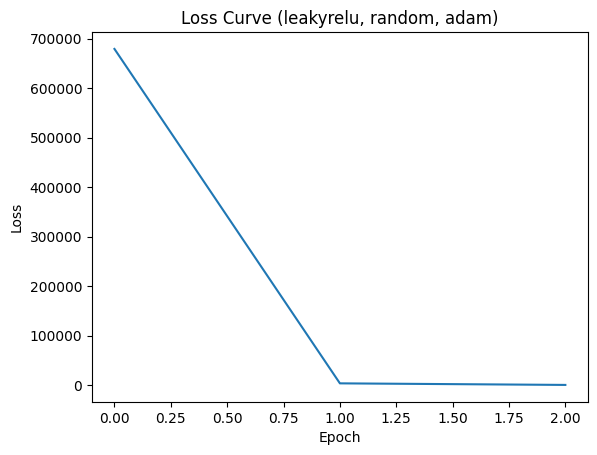


Activation=leakyrelu, Init=random, Optimizer=rmsprop


100%|██████████| 782/782 [01:38<00:00,  7.96it/s]


Epoch 1, Loss: 357100.9503


100%|██████████| 782/782 [01:39<00:00,  7.86it/s]


Epoch 2, Loss: 32.5112


100%|██████████| 782/782 [01:37<00:00,  8.00it/s]


Epoch 3, Loss: 2.9230


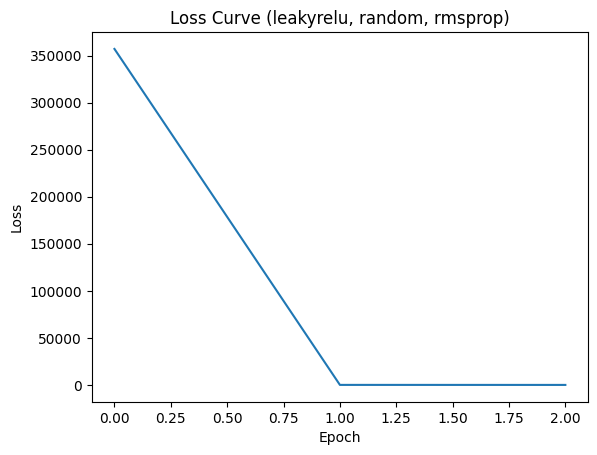


Activation=leakyrelu, Init=xavier, Optimizer=sgd


100%|██████████| 782/782 [01:36<00:00,  8.11it/s]


Epoch 1, Loss: 1.9095


100%|██████████| 782/782 [01:37<00:00,  8.04it/s]


Epoch 2, Loss: 1.5952


100%|██████████| 782/782 [01:36<00:00,  8.10it/s]


Epoch 3, Loss: 1.4422


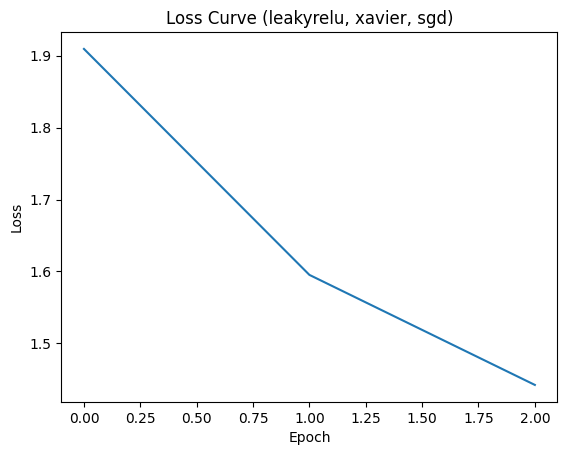


Activation=leakyrelu, Init=xavier, Optimizer=adam


100%|██████████| 782/782 [01:39<00:00,  7.83it/s]


Epoch 1, Loss: 1.3782


100%|██████████| 782/782 [01:40<00:00,  7.81it/s]


Epoch 2, Loss: 1.0077


100%|██████████| 782/782 [01:39<00:00,  7.89it/s]


Epoch 3, Loss: 0.8687


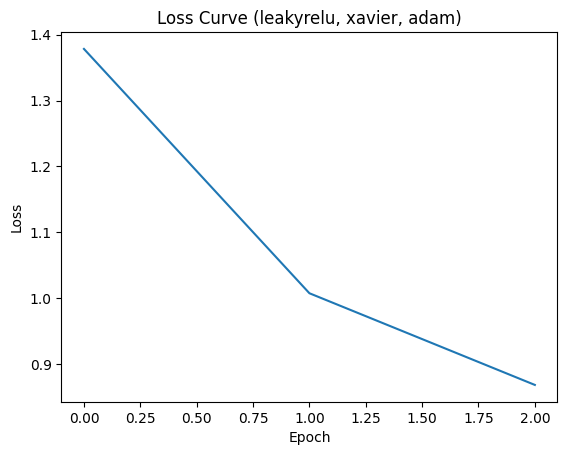


Activation=leakyrelu, Init=xavier, Optimizer=rmsprop


100%|██████████| 782/782 [01:39<00:00,  7.89it/s]


Epoch 1, Loss: 1.3802


100%|██████████| 782/782 [01:38<00:00,  7.91it/s]


Epoch 2, Loss: 1.0182


100%|██████████| 782/782 [01:39<00:00,  7.87it/s]


Epoch 3, Loss: 0.8694


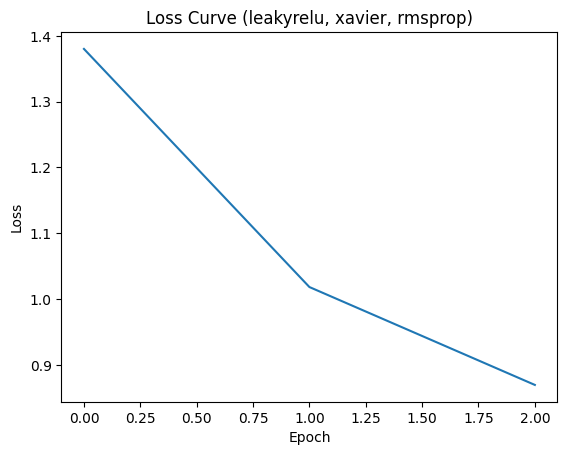


Activation=leakyrelu, Init=kaiming, Optimizer=sgd


100%|██████████| 782/782 [01:37<00:00,  8.00it/s]


Epoch 1, Loss: 1.7561


100%|██████████| 782/782 [01:37<00:00,  8.02it/s]


Epoch 2, Loss: 1.4348


100%|██████████| 782/782 [01:37<00:00,  8.02it/s]


Epoch 3, Loss: 1.3057


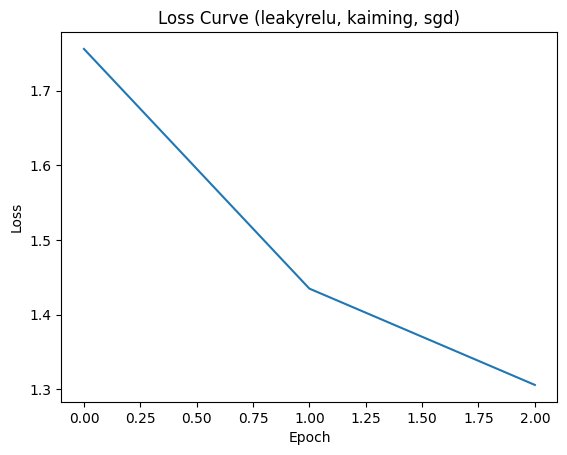


Activation=leakyrelu, Init=kaiming, Optimizer=adam


100%|██████████| 782/782 [01:39<00:00,  7.83it/s]


Epoch 1, Loss: 1.4767


100%|██████████| 782/782 [01:40<00:00,  7.76it/s]


Epoch 2, Loss: 1.0823


100%|██████████| 782/782 [01:40<00:00,  7.82it/s]


Epoch 3, Loss: 0.9317


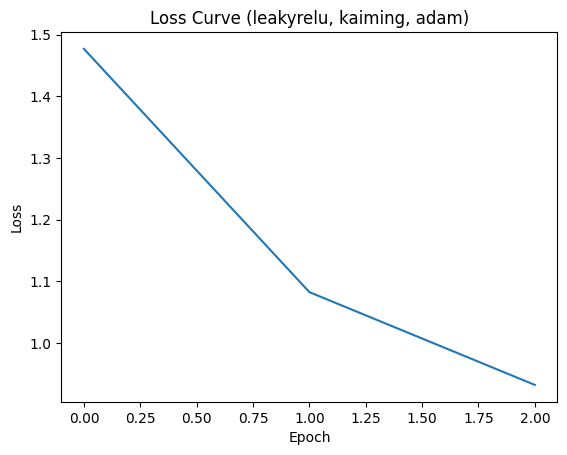


Activation=leakyrelu, Init=kaiming, Optimizer=rmsprop


100%|██████████| 782/782 [01:39<00:00,  7.86it/s]


Epoch 1, Loss: 1.4541


100%|██████████| 782/782 [01:39<00:00,  7.86it/s]


Epoch 2, Loss: 1.0368


100%|██████████| 782/782 [01:38<00:00,  7.92it/s]


Epoch 3, Loss: 0.8872


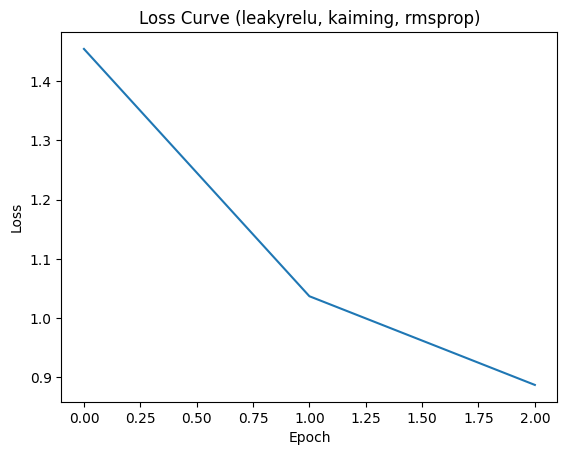

In [10]:
activations = ["relu", "tanh", "leakyrelu"]
inits = ["random", "xavier", "kaiming"]
opts = ["sgd", "adam", "rmsprop"]

results = []

for act in activations:
    for init in inits:
        for opt_name in opts:
            print(f"\nActivation={act}, Init={init}, Optimizer={opt_name}")

            model = CNN(act).to(device)
            init_weights(model, init)

            if opt_name == "sgd":
                optimizer = optim.SGD(model.parameters(), lr=0.01)
            elif opt_name == "adam":
                optimizer = optim.Adam(model.parameters(), lr=0.001)
            elif opt_name == "rmsprop":
                optimizer = optim.RMSprop(model.parameters(), lr=0.001)

            criterion = nn.CrossEntropyLoss()

            losses = train_model(model, optimizer, criterion, epochs=3)
            acc = evaluate_model(model)

            results.append((act, init, opt_name, acc))

            # Visual: Loss Curve
            plt.figure()
            plt.plot(losses)
            plt.title(f"Loss Curve ({act}, {init}, {opt_name})")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.show()


Accuracy Comparision

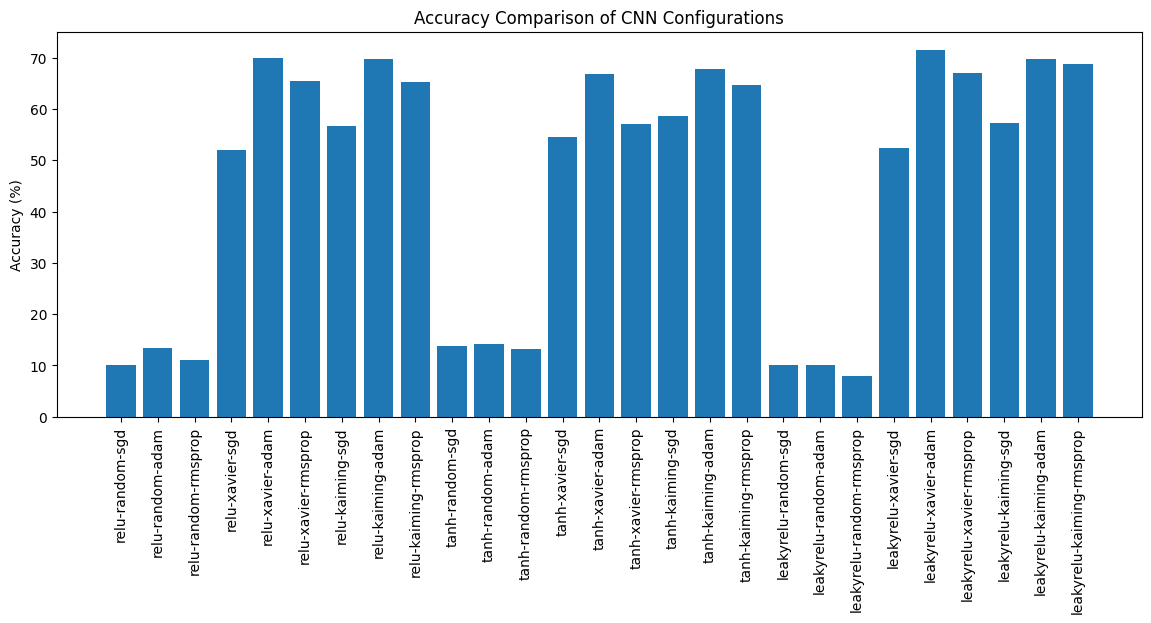

In [11]:
labels = [f"{a}-{i}-{o}" for a,i,o,_ in results]
accs = [r[3] for r in results]

plt.figure(figsize=(14,5))
plt.bar(labels, accs)
plt.xticks(rotation=90)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of CNN Configurations")
plt.show()


In [17]:
import pandas as pd

In [20]:
comparision_table=pd.DataFrame(results,
                              columns=["Activation Function"," Weight Initialization", "Optimizer", " Accuracy(%)"] )
comparision_table

,Activation Function,Weight Initialization,Optimizer,Accuracy(%)
0,relu,random,sgd,10.00
1,relu,random,adam,13.35
2,relu,random,rmsprop,10.99
3,relu,xavier,sgd,51.93
4,relu,xavier,adam,69.89
5,relu,xavier,rmsprop,65.43
6,relu,kaiming,sgd,56.68
7,relu,kaiming,adam,69.69
8,relu,kaiming,rmsprop,65.20
9,tanh,random,sgd,13.79


BEST CNN MODEL

In [12]:
best = max(results, key=lambda x: x[3])
print("Best CNN:", best)

Best CNN: ('leakyrelu', 'xavier', 'adam', 71.46)


Transfer Learning - Resnet-18

In [13]:
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

optimizer = optim.Adam(resnet.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

train_model(resnet, optimizer, criterion, epochs=1)
resnet_acc = evaluate_model(resnet)
print("ResNet-18 Accuracy:", resnet_acc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]
100%|██████████| 782/782 [11:45<00:00,  1.11it/s]


Epoch 1, Loss: 0.9935
ResNet-18 Accuracy: 76.66


In [14]:
resnet_acc = evaluate_model(resnet)
print("ResNet-18 Accuracy:", resnet_acc)

ResNet-18 Accuracy: 76.79


CNN VS Resnet-18

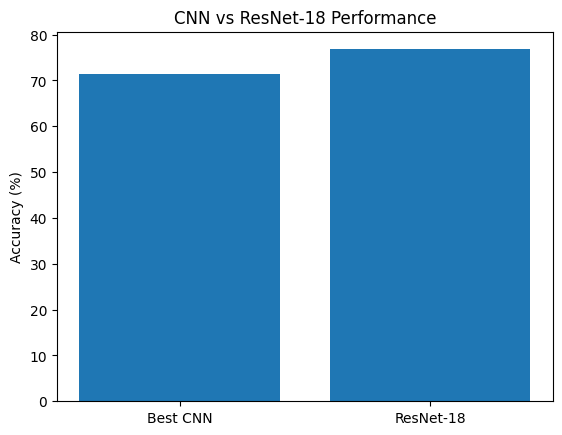

In [15]:
plt.figure()
plt.bar(["Best CNN", "ResNet-18"], [best[3], resnet_acc])
plt.ylabel("Accuracy (%)")
plt.title("CNN vs ResNet-18 Performance")
plt.show()
